### Importando dados pelo Pandas

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import sqlite3

### Configurando e lendo dataframe Pandas

In [5]:
df = pd.read_csv('data/vendas_desafio.csv', sep=',', parse_dates=['data_venda'])
df.head()

,id_venda,data_venda,cliente,produto,categoria,quantidade,preco_unitario,vendedor,cidade,estado
0,1,2024-09-27,Pietra,Mouse,Eletrônicos,3,84.74,Ana,Belo Horizonte,RJ
1,2,2024-01-21,Vinicius,Monitor,Eletrônicos,3,950.34,Bruno,São Paulo,RS
2,3,2024-08-02,Yago,Mouse,Eletrônicos,3,79.13,Eduardo,Curitiba,SP
3,4,2024-04-09,Lara,Notebook,Eletrônicos,3,3471.47,Ana,Rio de Janeiro,RJ
4,5,2024-05-29,Levi,Fone,Eletrônicos,4,208.32,Eduardo,São Paulo,RS


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_venda        10000 non-null  int64         
 1   data_venda      10000 non-null  datetime64[us]
 2   cliente         10000 non-null  str           
 3   produto         10000 non-null  str           
 4   categoria       10000 non-null  str           
 5   quantidade      10000 non-null  int64         
 6   preco_unitario  10000 non-null  float64       
 7   vendedor        10000 non-null  str           
 8   cidade          10000 non-null  str           
 9   estado          10000 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(6)
memory usage: 781.4 KB


### Parte 1 - SQL

#### Conexão com SQLite3

In [11]:
conn = sqlite3.connect(':memory:')
df.to_sql('vendas', conn, index=False, if_exists='replace')
print("Conexão com o banco de dados SQLite estabelecida.")

def sql(query):
    return pd.read_sql_query(query, conn)

Conexão com o banco de dados SQLite estabelecida.


In [12]:
sql("""

    SELECT * FROM vendas

""")

,id_venda,data_venda,cliente,produto,categoria,quantidade,preco_unitario,vendedor,cidade,estado
0,1,2024-09-27 00:00:00,Pietra,Mouse,Eletrônicos,3,84.74,Ana,Belo Horizonte,RJ
1,2,2024-01-21 00:00:00,Vinicius,Monitor,Eletrônicos,3,950.34,Bruno,São Paulo,RS
2,3,2024-08-02 00:00:00,Yago,Mouse,Eletrônicos,3,79.13,Eduardo,Curitiba,SP
3,4,2024-04-09 00:00:00,Lara,Notebook,Eletrônicos,3,3471.47,Ana,Rio de Janeiro,RJ
4,5,2024-05-29 00:00:00,Levi,Fone,Eletrônicos,4,208.32,Eduardo,São Paulo,RS
...,...,...,...,...,...,...,...,...,...,...
9995,9996,2024-11-19 00:00:00,Cauã,Teclado,Eletrônicos,1,141.84,Carlos,Belo Horizonte,RJ
9996,9997,2024-01-22 00:00:00,Luara,Livro Python,Livros,1,114.31,Carlos,Belo Horizonte,SP
9997,9998,2024-07-20 00:00:00,Vitória,Livro Python,Livros,2,119.01,Eduardo,Porto Alegre,RJ
9998,9999,2024-07-15 00:00:00,Ravi Lucca,Mochila,Acessórios,4,183.76,Bruno,Curitiba,PR


#### Questão 1 - Faturamento total por produto

In [17]:
# Qual o faturamento total por produto?

sql("""

    SELECT 
    produto, 
    ROUND(SUM(quantidade * preco_unitario), 2) AS faturamento_total
    FROM vendas
    GROUP BY produto
    ORDER BY faturamento_total DESC

""")


,produto,faturamento_total
0,Notebook,8290852.39
1,Mesa,3092939.21
2,Monitor,2364641.86
3,Cadeira,1629832.30
4,Fone,495633.09
5,Mochila,460376.91
6,Teclado,384771.59
7,Livro Python,296630.22
8,Livro SQL,247460.70
9,Mouse,205764.16


#### Questão 2 - Faturamento total por categoria

In [19]:
# Qual o faturamento total por categoria?

sql("""

    SELECT 
    categoria, 
    ROUND(SUM(quantidade * preco_unitario), 2) AS Fat_total_Cat
    FROM vendas
    GROUP BY categoria
    ORDER BY Fat_total_Cat DESC

""")

,categoria,Fat_total_Cat
0,Eletrônicos,11741663.09
1,Móveis,4722771.51
2,Livros,544090.92
3,Acessórios,460376.91


#### Questão 3 - Ticket médio por cliente
    ##### Ticket médio = Faturamento total cliente / nº de compras

In [31]:
# Qual o ticket médio por cliente?

sql("""
    SELECT 
        cliente,
        COUNT(id_venda)                                         AS total_compras,
        ROUND(SUM(quantidade * preco_unitario), 2)              AS faturamento_total,
        ROUND(SUM(quantidade * preco_unitario) / COUNT(*), 2)   AS ticket_medio
    FROM vendas
    GROUP BY cliente
    ORDER BY ticket_medio DESC
    LIMIT 10
""")

,cliente,total_compras,faturamento_total,ticket_medio
0,Mathias,41,122641.69,2991.26
1,Isabelly,27,80187.94,2969.92
2,Thiago,38,107474.24,2828.27
3,Danilo,28,78792.49,2814.02
4,Nicole,31,85804.88,2767.90
5,Ravy,39,105380.55,2702.07
6,Rafaela,35,93684.14,2676.69
7,Ana Carolina,28,73752.02,2634.00
8,Leandro,31,80460.60,2595.50
9,Evelyn,40,103511.35,2587.78


#### Questão 4 - Faturamento Total por vendedor

In [ ]:
# Qual o faturamento total por vendedor?

sql("""

    SELECT 
    vendedor,
        ROUND(SUM(quantidade * preco_unitario), 2) AS faturamento_total
    FROM vendas
    GROUP BY vendedor
    ORDER BY faturamento_total DESC

""")

,vendedor,faturamento_total
0,Ana,3544588.45
1,Bruno,3501930.96
2,Eduardo,3477302.18
3,Carlos,3476724.22
4,Daniela,3468356.62


#### Questão 5 - Faturamento por mês

In [ ]:
# Qual o faturamento por mês?

sql("""

    SELECT 
    strftime('%Y-%m', data_venda)                   AS mes_ano,
        ROUND(SUM(quantidade * preco_unitario), 2)  AS faturamento_total
    FROM vendas
    GROUP BY mes_ano
    ORDER BY mes_ano

""")

,mes_ano,faturamento_total
0,2024-01,1332505.24
1,2024-02,1414699.44
2,2024-03,1561420.22
3,2024-04,1571459.42
4,2024-05,1537043.09
5,2024-06,1346568.09
6,2024-07,1528937.90
7,2024-08,1531974.02
8,2024-09,1560269.23
9,2024-10,1423821.79


#### Questão 6 - Top 5 produtos mais vendidos

In [37]:
# Quais são os 5 produtos mais vendidos?

sql("""

    SELECT 
    produto,
        SUM(quantidade) AS qtd_total
    FROM vendas
    GROUP BY produto
    ORDER BY qtd_total DESC
    LIMIT 5

""")

,produto,qtd_total
0,Monitor,2613
1,Mouse,2581
2,Mesa,2581
3,Teclado,2566
4,Mochila,2557


#### Questão 7 - Cidade com maior faturamento

In [33]:
# Qual a cidade possui maior faturamento?

sql("""

    SELECT 
        cidade,
        estado,
        ROUND(SUM(quantidade * preco_unitario), 2) AS faturamento_total
    FROM vendas
    GROUP BY cidade, estado
    ORDER BY faturamento_total DESC
    LIMIT 5

""")

,cidade,estado,faturamento_total
0,Rio de Janeiro,PR,792783.83
1,São Paulo,PR,788272.13
2,São Paulo,RJ,772185.34
3,Curitiba,SP,758251.40
4,Belo Horizonte,RS,751838.73


#### Questão 8 - Cliente mais compra em valor

In [35]:
# Qual cliente mais comprou em valor?

sql("""

    SELECT 
        cliente,
        COUNT(id_venda)                             AS total_compras,
        ROUND(SUM(quantidade * preco_unitario), 2)  AS valor_total_compras
    FROM vendas
    GROUP BY cliente
    ORDER BY valor_total_compras DESC
    LIMIT 5

""")

,cliente,total_compras,valor_total_compras
0,Mathias,41,122641.69
1,Asafe,47,121077.15
2,Lunna,43,111178.92
3,Carlos Eduardo,45,110931.92
4,Thiago,38,107474.24


#### Criar tabela resumo dentro do BD

In [40]:
# Criar uma tabela resumo _vendas com: produto, categoria, quantidade_total, faturamento_total

conn.execute("""
    CREATE TABLE IF NOT EXISTS vendas_resumo AS
    SELECT
        produto,
        categoria,
        SUM(quantidade) AS quantidade_total,
        ROUND(SUM(quantidade * preco_unitario), 2) AS faturamento_total
    FROM vendas
    GROUP BY produto, categoria
    ORDER BY faturamento_total DESC
""")

conn.commit()
print("Tabela resumo 'vendas_resumo' criada com sucesso.")

# Conferir
conn.execute("SELECT * FROM vendas_resumo")


Tabela resumo 'vendas_resumo' criada com sucesso.


In [42]:
sql("""
    SELECT * FROM vendas_resumo
""")

,produto,categoria,quantidade_total,faturamento_total
0,Notebook,Eletrônicos,2364,8290852.39
1,Mesa,Móveis,2581,3092939.21
2,Monitor,Eletrônicos,2613,2364641.86
3,Cadeira,Móveis,2319,1629832.30
4,Fone,Eletrônicos,2469,495633.09
5,Mochila,Acessórios,2557,460376.91
6,Teclado,Eletrônicos,2566,384771.59
7,Livro Python,Livros,2470,296630.22
8,Livro SQL,Livros,2474,247460.70
9,Mouse,Eletrônicos,2581,205764.16


### Parte 2 - Python

#### Questão 1 - Coluna de faturamento

In [43]:
# Criar coluna faturamento = quantidade * preco_unitario

df['faturamento'] = df['quantidade'] * df['preco_unitario']
df[['produto', 'categoria', 'quantidade', 'preco_unitario', 'faturamento']].head()

,produto,categoria,quantidade,preco_unitario,faturamento
0,Mouse,Eletrônicos,3,84.74,254.22
1,Monitor,Eletrônicos,3,950.34,2851.02
2,Mouse,Eletrônicos,3,79.13,237.39
3,Notebook,Eletrônicos,3,3471.47,10414.41
4,Fone,Eletrônicos,4,208.32,833.28


#### Questão 2 - Agrupar faturamento por produto

In [ ]:
# Agrupar faturamento por produto

faturamento_produto = (
    df.groupby('produto')
    ['faturamento'].sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'faturamento': 'faturamento_total'})
)

faturamento_produto

,produto,faturamento_total
0,Notebook,8290852.39
1,Mesa,3092939.21
2,Monitor,2364641.86
3,Cadeira,1629832.30
4,Fone,495633.09
5,Mochila,460376.91
6,Teclado,384771.59
7,Livro Python,296630.22
8,Livro SQL,247460.70
9,Mouse,205764.16


#### Questão 3 - Agrupar faturamento por categoria

In [ ]:
# Agrupar faturamento por categoria

fat_categoria = (
    df.groupby('categoria')
    ['faturamento'].sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'faturamento': 'fat_categoria_total'})
)

fat_categoria

,categoria,fat_categoria_total
0,Eletrônicos,11741663.09
1,Móveis,4722771.51
2,Livros,544090.92
3,Acessórios,460376.91


#### Questão 4 - Agrupar faturamento por cliente

In [ ]:
# Agrupar faturamento por cliente

fat_cliente = (
    df.groupby('cliente')
    ['faturamento'].sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'faturamento': 'fat_cliente_total'})
)

fat_cliente

,cliente,fat_cliente_total
0,Mathias,122641.69
1,Asafe,121077.15
2,Lunna,111178.92
3,Carlos Eduardo,110931.92
4,Thiago,107474.24
...,...,...
277,Marcos Vinicius,24779.10
278,Guilherme,24450.71
279,Arthur Gabriel,24413.17
280,Mariane,22230.06


### Parte 3 - Insights de Negócio

#### Questão 1 - Criar gráfico de faturamento por categoria

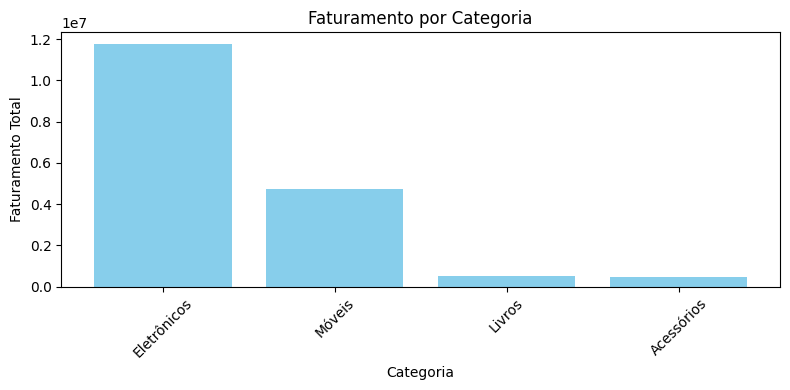

In [54]:
# Criar gráfico de faturamento por categoria

plt.figure(figsize=(8, 4))
bars = plt.bar(fat_categoria['categoria'], fat_categoria['fat_categoria_total'], color='skyblue')
plt.title('Faturamento por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Faturamento Total')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Questão 2 - Criar gráfico de faturamento por produto

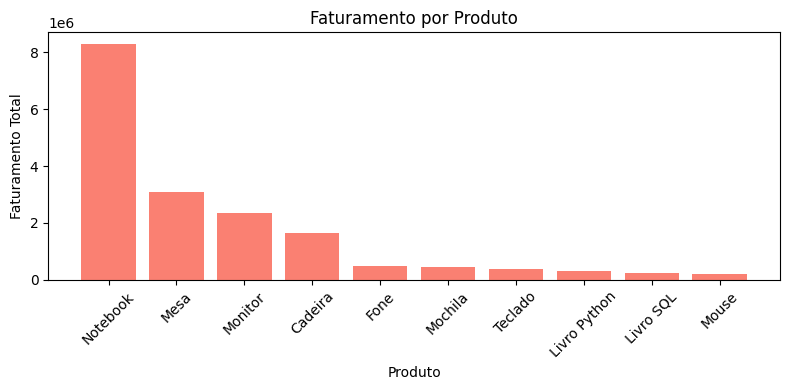

In [52]:
# Criar gráfico de faturamento por produto
plt.figure(figsize=(8, 4))
bars = plt.bar(faturamento_produto['produto'], faturamento_produto['faturamento_total'], color='salmon')
plt.title('Faturamento por Produto')
plt.xlabel('Produto')
plt.ylabel('Faturamento Total')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Questão 3 - Criar gráfico com maior vendendor

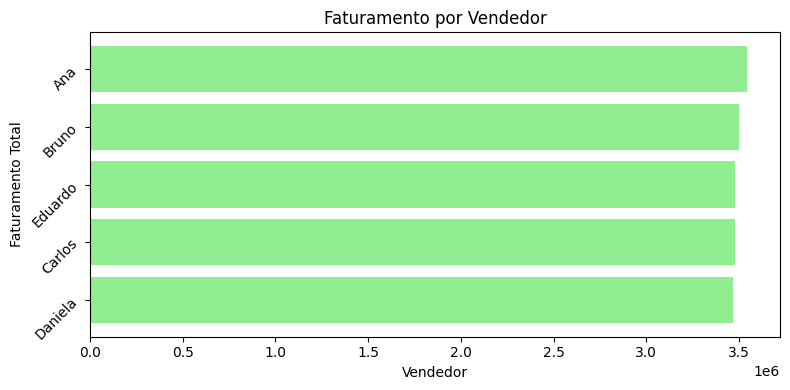

In [58]:
# Criar um gráfico com vendedor que mais vendeu

faturamento_vendedor = (
    df.groupby('vendedor')
    ['faturamento'].sum()
    .sort_values(ascending=True)
    .reset_index()
    .rename(columns={'faturamento': 'faturamento_total'})
)

plt.figure(figsize=(8, 4))
barh = plt.barh(faturamento_vendedor['vendedor'], faturamento_vendedor['faturamento_total'], color='lightgreen')
plt.title('Faturamento por Vendedor')
plt.xlabel('Vendedor')
plt.ylabel('Faturamento Total')
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

#### Questão 4 - Criar gráfico com mês que vende mais

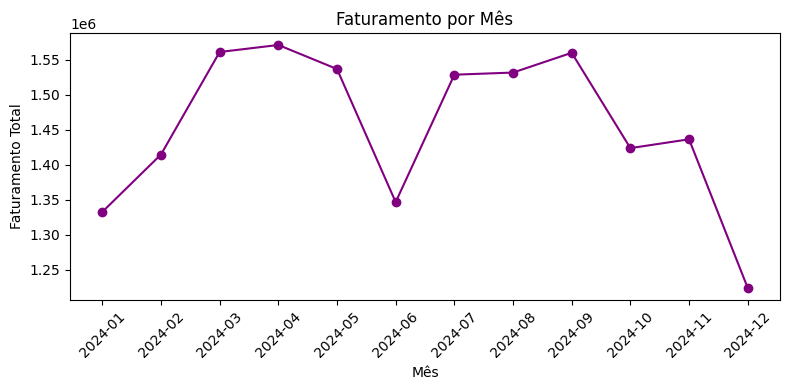

In [60]:
# Criar um grafico de linha com o mês que mais vendeu
faturamento_mes = (
    df.groupby(df['data_venda'].dt.to_period('M'))['faturamento']
    .sum()
    .sort_index()
    .reset_index()
    .rename(columns={'data_venda': 'mes_ano', 'faturamento': 'faturamento_total'})
)   

plt.figure(figsize=(8, 4))
plt.plot(faturamento_mes['mes_ano'].astype(str), faturamento_mes['faturamento_total'], marker='o', color='purple')
plt.title('Faturamento por Mês')
plt.xlabel('Mês')
plt.ylabel('Faturamento Total')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Questão 5 - Existe cliente que comprou mais vezes

In [ ]:
# Existe cliente que comprou mais de 1 vez
 
compras_cliente = (
    df.groupby('cliente')
    ['id_venda'].count()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'id_venda': 'total_compras'})
)   

compras_cliente.head()

,cliente,total_compras
0,Alexandre,50
1,Benício,49
2,Luan,49
3,Allana,48
4,Arthur,48


#### Quetão 6 - Criar arquivo .csv

In [69]:
# Exportar arquivo resumo_vendas.csv com colunas Produto, categoria, quantidade_total, faturamento_total

resumo_vendas = df.groupby(['produto', 'categoria']).agg(
    quantidade_total=('quantidade', 'sum'),
    faturamento_total=('faturamento', 'sum')
).reset_index()
resumo_vendas.to_csv('resumo_vendas.csv', index=False)
